In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/ECS 189G/189G Project/ECS189G_Winter_2025_Source_Code_Template.zip" -d "/content/project"

In [ ]:
!unzip "/content/project/ECS189G_Winter_2025_Source_Code_Template/data/stage_4_data.zip" -d "/content/project/ECS189G_Winter_2025_Source_Code_Template/data"

In [ ]:

!pip install torch

# Install scikit-learn
!pip install scikit-learn

In [5]:
import pandas as pd

df = pd.read_csv(
    "/content/project/ECS189G_Winter_2025_Source_Code_Template/data/stage_4_data/text_generation/data",
    header=0,
    quotechar='"',
    engine="python"
)

jokes = df["Joke"].dropna().str.lower().tolist()
print(jokes[:5])


['what did the bartender say to the jumper cables? you better not try to start anything.', "don't you hate jokes about german sausage? they're the wurst!", 'two artists had an art contest... it ended in a draw', 'why did the chicken cross the playground? to get to the other slide.', 'what gun do you use to hunt a moose? a moosecut!']


In [6]:
import re
from collections import Counter

# Basic tokenization: lowercase, remove punctuation, split by whitespace
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

tokenized_jokes = [tokenize(joke) for joke in jokes]
all_words = [word for joke in tokenized_jokes for word in joke]


# Build vocab
special_tokens = ["<pad>", "<unk>"]
vocab = special_tokens + sorted(set(all_words))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(vocab)

print(f"Vocab size: {vocab_size}")
print(tokenized_jokes[0])

def tokens_to_indices(tokens, word2idx):
    return [word2idx.get(token, word2idx["<unk>"]) for token in tokens]




Vocab size: 4672
['what', 'did', 'the', 'bartender', 'say', 'to', 'the', 'jumper', 'cables', 'you', 'better', 'not', 'try', 'to', 'start', 'anything']


In [7]:
import torch
from torch.utils.data import Dataset
sequences = []

for tokens in tokenized_jokes:
    if len(tokens) > 5:
        for i in range(len(tokens) - 5):
            input_seq = tokens[i:i+5]
            target = tokens[i+5]
            input_tensor = torch.tensor(tokens_to_indices(input_seq, word2idx), dtype=torch.long)
            target_tensor = torch.tensor(word2idx.get(target, word2idx["<unk>"]), dtype=torch.long)
            sequences.append((input_tensor, target_tensor))


print("Words:", [idx2word[idx.item()] for idx in sequences[0][0]])
print("Target word:", idx2word[sequences[0][1].item()])



Words: ['what', 'did', 'the', 'bartender', 'say']
Target word: to


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class JokeDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

dataset = JokeDataset(sequences)

from torch.utils.data import random_split, DataLoader

# Define lengths for the split
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [60]:
import torch.nn as nn

class JokeRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=512, num_layers=2, dropout=0.3):
        super(JokeRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)  # Double hidden_dim due to bidirectional


    def forward(self, x):
        x = self.embedding(x)            # [batch, seq_len, embed_dim]
        output, _ = self.rnn(x)          # [batch, seq_len, hidden_dim]
        output = self.layer_norm(output) # [batch, seq_len, hidden_dim]
        out = self.fc(output[:, -1, :])  # Use last hidden state for prediction
        return out                      # [batch, vocab_size]

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
model = JokeRNN(vocab_size, embed_dim=128, hidden_dim=256)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loss = []
train_acc = []
test_loss = []
test_acc = []
print(model)



def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    # Calculate metrics
    precision = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    accuracy = (np.array(all_preds) == np.array(all_targets)).mean()

    return avg_loss, accuracy, precision, recall, f1

# Assuming you created the DataLoader `loader`
for epoch in range(50):  # You can adjust number of epochs
    total_loss = 0
    correct = 0
    total = 0
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
    epoch_acc = correct/total
    epoch_loss = total_loss / len(train_loader.dataset)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    #eval
    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate_model(model, test_loader, criterion)
    test_loss.append(val_loss)
    test_acc.append(val_acc)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")
    print(f"Test Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print("-" * 50)

JokeRNN(
  (embedding): Embedding(4672, 128)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=512, out_features=4672, bias=True)
)
Epoch 1, Train Loss: 6.7536, Train Acc: 0.0971
Test Loss: 6.3631, Acc: 0.1116, Precision: 0.0691, Recall: 0.1116, F1: 0.0710
--------------------------------------------------
Epoch 2, Train Loss: 4.7169, Train Acc: 0.1805
Test Loss: 6.3840, Acc: 0.1485, Precision: 0.1226, Recall: 0.1485, F1: 0.1198
--------------------------------------------------
Epoch 3, Train Loss: 2.9938, Train Acc: 0.3486
Test Loss: 6.7977, Acc: 0.1508, Precision: 0.1373, Recall: 0.1508, F1: 0.1342
--------------------------------------------------
Epoch 4, Train Loss: 1.6513, Train Acc: 0.6041
Test Loss: 7.1826, Acc: 0.1669, Precision: 0.1700, Recall: 0.1669, F1: 0.1621
--------------------------------------------------
Epoch 5, Train Loss: 0.8252,

KeyboardInterrupt: 

[6.3630589379204645, 6.384004963768853, 6.797701553062156, 7.182583808898926, 7.652943964357729, 7.787099891238743, 8.01738636581986, 8.115816469545718, 8.067526057914451, 8.124783356984457, 8.124797715081108, 8.164596751884178, 8.19382874170939, 8.220570069772226, 8.29675363611292, 8.444648018589726, 8.93864921287254]


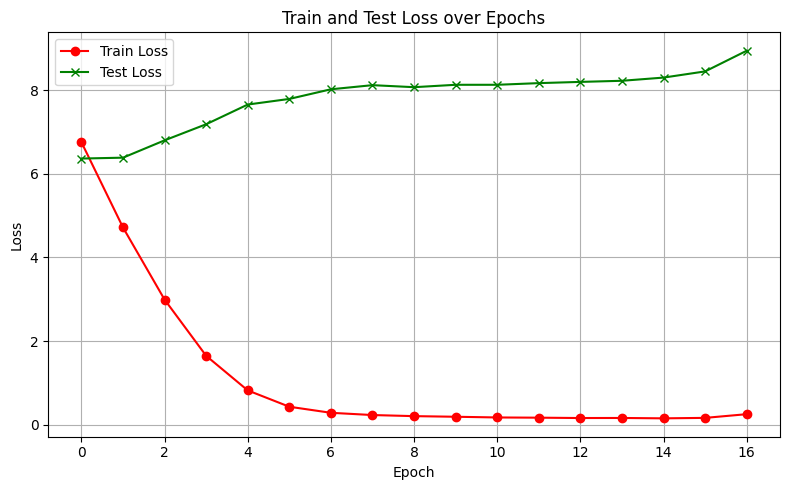

In [62]:
import matplotlib.pyplot as plt
print(test_loss)
plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Train Loss', color='red', marker='o')
plt.plot(test_loss, label='Test Loss', color='green', marker='x')
plt.title("Train and Test Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [67]:


def test_text_gen_model(model, startwords, word2idx, idx2word, num_words=15):
  model.eval()
  words = startwords.lower().split()
  input_seq = [word2idx.get(w, word2idx["<unk>"]) for w in words]

  for _ in range(num_words):
        input_tensor = torch.tensor(input_seq[-5:], dtype=torch.long).unsqueeze(0)  # [1, seq_len]
        with torch.no_grad():
            output = model(input_tensor)
            predicted_idx = output.argmax(dim=1).item()
            predicted_word = idx2word[predicted_idx]


            words.append(predicted_word)
            input_seq.append(predicted_idx)
            if predicted_word in ['.', '!', '?']:  # Stop if sentence ends
                break

  return ' '.join(words)


start_words = "Why did the chicken cross"
generated_text = test_text_gen_model(model, start_words, word2idx, idx2word)
print(generated_text)

why did the chicken cross the road to get to the other side because the has the udder why did
